# Linear Regression từ A đến Z: Dự đoán giá thuê căn hộ ở Sydney

**Bối cảnh:** Bạn là data scientist của một công ty bất động sản. Bạn có dữ liệu 100 căn hộ và muốn biết: giá thuê mỗi tuần (`rent`, AUD) phụ thuộc vào những yếu tố nào?

- `size`: diện tích (m²)
- `distance`: khoảng cách đến CBD (km)
- `parking`: có chỗ đậu xe hay không (1 = có, 0 = không)
- `bedrooms`: số phòng ngủ

## Bước 0: Tạo dữ liệu
Dữ liệu được tạo giả lập. **Công thức thật** được giấu trong cell này, bạn đừng nhìn vội! Cuối bài sẽ so sánh mô hình tìm được với công thức thật.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

rng = np.random.default_rng(7)
n = 100
size = rng.uniform(30, 120, n).round()
distance = np.clip(2 + 0.12*size + rng.normal(0, 4, n), 1, None).round(1)
parking = rng.binomial(1, 0.4, n)
bedrooms = np.clip(np.round(size/35 + rng.normal(0, 0.3, n)), 1, 4).astype(int)
rent = (350 + 7*size - 20*distance + 80*parking + rng.normal(0, 60, n)).round()
df = pd.DataFrame(dict(rent=rent, size=size, distance=distance, parking=parking, bedrooms=bedrooms))
df.head()

,rent,size,distance,parking,bedrooms
0,844.0,86.0,4.2,1,2
1,798.0,111.0,14.1,0,3
2,853.0,100.0,10.4,0,3
3,550.0,50.0,8.7,0,2
4,450.0,57.0,17.8,1,2


## Bước 1: Khám phá dữ liệu (EDA)
Luôn nhìn dữ liệu trước khi fit mô hình.

In [2]:
df.corr().round(2)

,rent,size,distance,parking,bedrooms
rent,1.00,0.77,0.11,0.28,0.65
size,0.77,1.00,0.63,-0.00,0.88
distance,0.11,0.63,1.00,-0.10,0.61
parking,0.28,-0.00,-0.10,1.00,-0.01
bedrooms,0.65,0.88,0.61,-0.01,1.00


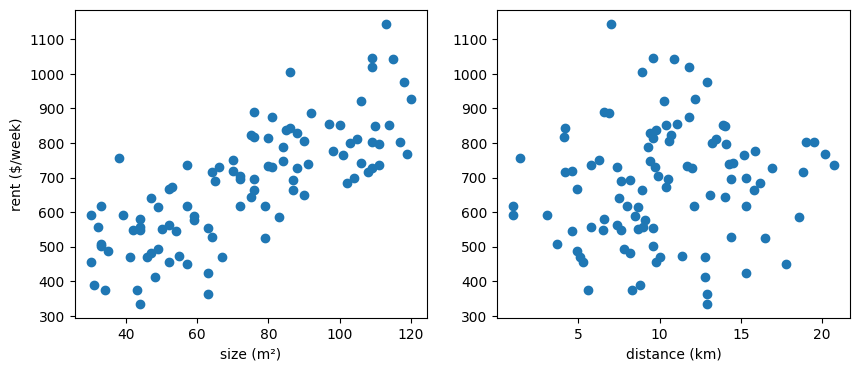

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(df['size'], df['rent']); ax[0].set_xlabel('size (m²)'); ax[0].set_ylabel('rent ($/week)')
ax[1].scatter(df['distance'], df['rent']); ax[1].set_xlabel('distance (km)')
plt.show()

## Bước 2: Simple Linear Regression, `rent ~ size`

In [4]:
# Cách 1: tự tính bằng công thức OLS
x, y = df['size'], df['rent']
b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
b0 = y.mean() - b1 * x.mean()
print(f'b0 = {b0:.2f}, b1 = {b1:.4f}')

b0 = 313.34, b1 = 4.9823


In [5]:
# Cách 2: statsmodels (ra cùng kết quả, kèm p-value)
m1 = smf.ols('rent ~ size', data=df).fit()
print(m1.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    313.3402     32.487      9.645      0.000     248.872     377.809
size           4.9823      0.416     11.965      0.000       4.156       5.809


In [6]:
# Dự đoán: căn hộ 70 m²
m1.predict(pd.DataFrame({'size': [70]}))

0    662.10242
dtype: float64

## Bước 3: R² được tính như thế nào

In [7]:
SST = ((y - y.mean())**2).sum()   # sai số khi đoán bằng trung bình
SSE = (m1.resid**2).sum()          # sai số của mô hình
print(f'SST = {SST:,.0f}  SSE = {SSE:,.0f}  R² = 1 - SSE/SST = {1 - SSE/SST:.3f}')
print('statsmodels R²:', round(m1.rsquared, 3))

SST = 2,842,793  SSE = 1,155,221  R² = 1 - SSE/SST = 0.594
statsmodels R²: 0.594


## Bước 4: Multiple Linear Regression, `rent ~ size + distance + parking`

In [8]:
m2 = smf.ols('rent ~ size + distance + parking', data=df).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     233.7
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           5.61e-44
Time:                        09:31:51   Log-Likelihood:                -548.83
No. Observations:                 100   AIC:                             1106.
Df Residuals:                      96   BIC:                             1116.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    335.8396     19.467     17.252      0.0

In [9]:
# Dự đoán: 70 m², cách CBD 5 km, có parking
m2.predict(pd.DataFrame({'size': [70], 'distance': [5], 'parking': [1]}))

0    816.966327
dtype: float64

## Bước 5: Thêm `bedrooms`, biến 'thừa' và multicollinearity

In [10]:
m3 = smf.ols('rent ~ size + distance + parking + bedrooms', data=df).fit()
print(m3.summary().tables[1])
print('Adj R²  m2:', round(m2.rsquared_adj, 4), '  m3:', round(m3.rsquared_adj, 4))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    335.8671     19.573     17.160      0.000     297.010     374.724
size           7.3310      0.509     14.415      0.000       6.321       8.341
distance     -22.5582      1.800    -12.529      0.000     -26.132     -18.984
parking       78.5635     12.138      6.473      0.000      54.467     102.660
bedrooms       1.1611     16.127      0.072      0.943     -30.856      33.178
Adj R²  m2: 0.8758   m3: 0.8745


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import statsmodels.api as sm
X = sm.add_constant(df[['size', 'distance', 'parking', 'bedrooms']])
{c: round(vif(X.values, i), 2) for i, c in enumerate(X.columns) if c != 'const'}

{'size': np.float64(4.88),
 'distance': np.float64(1.71),
 'parking': np.float64(1.02),
 'bedrooms': np.float64(4.68)}

## Bước 6: Kiểm tra giả định (LINE) bằng residual plot

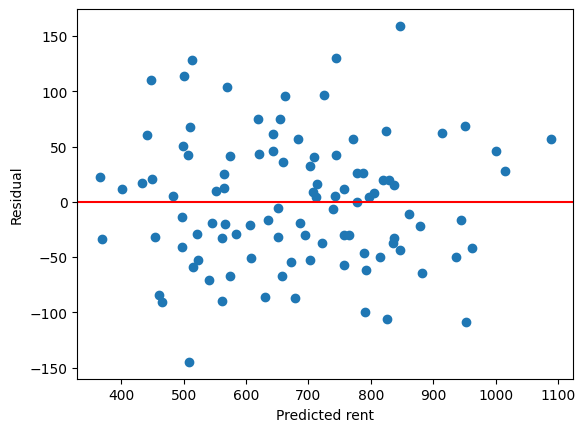

In [12]:
plt.scatter(m2.fittedvalues, m2.resid)
plt.axhline(0, color='red'); plt.xlabel('Predicted rent'); plt.ylabel('Residual')
plt.show()

## Bước 7: Train/test split, đánh giá khả năng dự đoán

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df[['size', 'distance', 'parking']]; y = df['rent']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_tr, y_tr)
pred = lr.predict(X_te)
print('Train R²:', round(lr.score(X_tr, y_tr), 3))
print('Test  R²:', round(r2_score(y_te, pred), 3))
print('Test RMSE:', round(mean_squared_error(y_te, pred)**0.5, 1), '$/week')

Train R²: 0.891
Test  R²: 0.823
Test RMSE: 68.9 $/week


## Bước 8: So sánh với công thức thật
Công thức dùng để tạo dữ liệu: `rent = 350 + 7·size − 20·distance + 80·parking + noise`

In [14]:
pd.DataFrame({'True': [350, 7, -20, 80], 'Model m2': m2.params.round(2)})

,True,Model m2
Intercept,350,335.84
size,7,7.36
distance,-20,-22.54
parking,80,78.57
